# 02 — Groups

Groups are the central algebraic structure behind the notion of **symmetry** in Geometric Deep Learning.

The main reference for this notebook is **§1.2, “Groups,”** of:

> Haitz Sáez de Ocáriz Borde and Michael Bronstein, *Mathematical Foundations of Geometric Deep Learning*, arXiv:2508.02723.

The goal is not to reproduce the section verbatim. Instead, we will develop the mathematical definitions, construct explicit examples, and use Python to experiment with finite groups and group actions.

The guiding pattern remains

$$
\text{definition}
\;\longrightarrow\;
\text{example/non-example}
\;\longrightarrow\;
\text{Python representation}
\;\longrightarrow\;
\text{experiment}
\;\longrightarrow\;
\text{GDL connection}.
$$

We will study:

- binary operations and groups;
- the group axioms;
- cyclic groups and rotations;
- permutation groups;
- abelian and non-abelian groups;
- subgroups and group order;
- homomorphisms and isomorphisms;
- group actions;
- orbits, invariance, and equivariance;
- connections between these ideas and Deep Learning.

## 1. Why groups?

A group is a set equipped with an operation that describes how its elements can be combined.

In many applications, the elements of a group represent **transformations**:

- rotations;
- reflections;
- translations;
- permutations;
- changes of coordinates;
- symmetries of physical systems.

This is exactly why groups appear so naturally in Geometric Deep Learning. A GDL model often needs to know which transformations should be regarded as symmetries of the data.

"Numbers measure sizes, and groups measure symmetries." - M. A. Armstrong

The article emphasizes this point at the beginning of §1.2: groups provide a mathematical language for transformations and symmetries, and GDL architectures use such structures as inductive biases.

## 2. Binary operations

Let $G$ be a set. A **binary operation** on $G$ is a rule

$$
\circ:G\times G\to G.
$$

Thus, given $a,b\in G$, the operation produces another element

$$
a\circ b\in G.
$$

The requirement that the result remains in $G$ is the **closure** property.

### Example

Addition is a binary operation on the integers:

$$
+:\mathbb Z\times\mathbb Z\to\mathbb Z.
$$

For example,

$$
3+(-5)=-2\in\mathbb Z.
$$

### Non-example

The operation

$$
\div:\mathbb Z\times\mathbb Z\to\mathbb Z
$$

is not a binary operation on $\mathbb Z$, because, for example,

$$
1\div2=\frac12\notin\mathbb Z.
$$

So the operation fails closure.

In [1]:
# A binary operation can be represented by a Python function.
def addition(a, b):
    # Addition maps two integers to another integer.
    return a + b

print(addition(3, -5))


-2


## 3. Definition of a group

A **group** is a set $G$ together with a binary operation $\circ$,

$$
(G,\circ),
$$

satisfying the following axioms.

### 1. Associativity

For all $a,b,c\in G$,

$$
(a\circ b)\circ c=a\circ(b\circ c).
$$

### 2. Identity

There exists an element $e\in G$ such that

$$
e\circ a=a\circ e=a
$$

for every $a\in G$.

### 3. Inverses

For every $a\in G$, there exists $a^{-1}\in G$ such that

$$
a\circ a^{-1}
=
a^{-1}\circ a
=
e.
$$

Together with closure, these axioms define a group.

**Important:** commutativity is *not* required.

Thus, in general,

$$
a\circ b\neq b\circ a.
$$

### Example: the integers under addition

The pair

$$
(\mathbb Z,+)
$$

is a group.

- Closure: $a+b\in\mathbb Z$.
- Associativity: $(a+b)+c=a+(b+c)$.
- Identity: $0$.
- Inverse of $a$: $-a$.

It is also **abelian**, because

$$
a+b=b+a.
$$

### Non-example: the natural numbers under addition

The pair

$$
(\mathbb N,+)
$$

is not a group if $\mathbb N=\{1,2,3,\ldots\}$, because an additive identity is absent.

Even if $0$ is included in $\mathbb N$, additive inverses are missing: for example, there is no natural number $n$ satisfying

$$
3+n=0.
$$

## 4. A first geometric example: rotations of a square

Consider the symmetries obtained by rotating a square.

The four rotations are

$$
C_4=
\{e,r,r^2,r^3\},
$$

where $r$ denotes rotation by $90^\circ$ and

$$
r^4=e.
$$

Equivalently,

$$
C_4=\{0^\circ,90^\circ,180^\circ,270^\circ\},
$$

with composition of rotations as the group operation.

For example,

$$
r\circ r=r^2,
$$

and

$$
r^3\circ r=r^4=e.
$$

This is the cyclic group $C_4$.

The article uses this square-rotation example to introduce the idea that group elements can represent geometric transformations.

In [2]:
import math

# Represent the rotations of a square by integers modulo 4.
C4 = {0, 1, 2, 3}

def compose_rotations(a, b):
    # Composition corresponds to adding rotation angles modulo 4.
    return (a + b) % 4

print("C4 =", C4)
print("90° followed by 180°:", compose_rotations(1, 2) * 90, "degrees")
print("90° followed by 270°:", compose_rotations(1, 3) * 90, "degrees")


C4 = {0, 1, 2, 3}
90° followed by 180°: 270 degrees
90° followed by 270°: 0 degrees


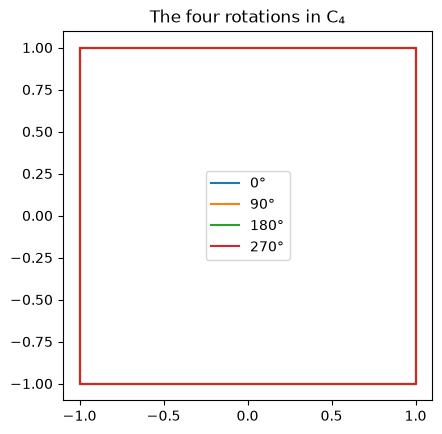

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def square_vertices(angle_degrees):
    # Start with the vertices of a square centered at the origin.
    vertices = np.array([
        [-1, -1],
        [ 1, -1],
        [ 1,  1],
        [-1,  1],
        [-1, -1],
    ])

    # Convert the angle from degrees to radians.
    theta = np.deg2rad(angle_degrees)

    # Build the two-dimensional rotation matrix.
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)],
    ])

    # Rotate every vertex.
    return vertices @ R.T


fig, ax = plt.subplots()

# Draw the four rotations of the square.
angles = [0, 90, 180, 270]

for angle in angles:
    v = square_vertices(angle)
    ax.plot(v[:, 0], v[:, 1], label=f"{angle}°")

ax.set_aspect("equal")
ax.set_title("The four rotations in C₄")
ax.legend()
plt.show()


### Computational observation

The four rotations form a finite set, but the important structure is not merely the list

$$
\{0^\circ,90^\circ,180^\circ,270^\circ\}.
$$

It is the **operation** of composing rotations.

This is a recurring theme in algebra:

> A group is not just a set of objects. It is a set together with an operation satisfying specific axioms.

## 5. Cayley tables

For a finite group, the operation can be displayed in a **Cayley table**.

For $C_4$, with addition modulo $4$,

$$
\begin{array}{c|cccc}
+ & 0&1&2&3\\
\hline
0&0&1&2&3\\
1&1&2&3&0\\
2&2&3&0&1\\
3&3&0&1&2
\end{array}
$$

Every row and every column contains every group element exactly once.

This is a finite manifestation of the cancellation properties that follow from the group axioms.

In [4]:
import pandas as pd

# Construct the Cayley table of C4 under addition modulo 4.
cayley_table = pd.DataFrame(
    [[compose_rotations(a, b) for b in C4] for a in C4],
    index=sorted(C4),
    columns=sorted(C4),
)

print(cayley_table)


   0  1  2  3
0  0  1  2  3
1  1  2  3  0
2  2  3  0  1
3  3  0  1  2


## 6. Abelian and non-abelian groups

A group $G$ is **abelian** if

$$
a\circ b=b\circ a
$$

for all $a,b\in G$.

The group $C_4$ is abelian.

But many important groups are not abelian.

### Example: the symmetric group

The symmetric group

$$
S_n
$$

is the group of all permutations of $n$ objects under composition.

For $n\geq3$, $S_n$ is non-abelian.

For example, two permutations can perform different transformations depending on which one is applied first.

This is particularly important for GDL because many symmetry groups are non-commutative.

In [5]:
from itertools import permutations

def compose_permutations(p, q):
    # Return p o q: first apply q, then apply p.
    return tuple(p[q[i]] for i in range(len(p)))

S3 = list(permutations(range(3)))

p = (1, 0, 2)  # Swap 0 and 1.
q = (0, 2, 1)  # Swap 1 and 2.

pq = compose_permutations(p, q)
qp = compose_permutations(q, p)

print("p o q =", pq)
print("q o p =", qp)
print("Do they commute?", pq == qp)


p o q = (1, 2, 0)
q o p = (2, 0, 1)
Do they commute? False


### Why non-commutativity matters

For a non-abelian group,

$$
g_1g_2\neq g_2g_1
$$

may occur.

This means that the **order of transformations matters**.

Rotations in three dimensions provide an important geometric example: rotating an object about the $x$-axis and then about the $y$-axis generally produces a different result from doing the operations in the reverse order.

This is one reason groups provide a richer language for geometric transformations than simply treating transformations as an unordered collection.

## 7. Subgroups and group order

A subset $H\subseteq G$ is a **subgroup** if it is itself a group under the operation inherited from $G$.

We write

$$
H\leq G.
$$

For example,

$$
C_2=\{e,r^2\}
$$

is a subgroup of

$$
C_4=\{e,r,r^2,r^3\}.
$$

The **order** of a finite group is its cardinality:

$$
|G|.
$$

Thus

$$
|C_4|=4,
\qquad
|C_2|=2.
$$

In [6]:
# The subgroup C2 consists of the identity and the 180-degree rotation.
C2 = {0, 2}

# Check closure of C2 under the C4 operation.
closure_check = {
    compose_rotations(a, b)
    for a in C2
    for b in C2
}

print("C2 =", C2)
print("Products of elements of C2 =", closure_check)
print("C2 is closed?", closure_check <= C2)


C2 = {0, 2}
Products of elements of C2 = {0, 2}
C2 is closed? True


## 8. Group homomorphisms

A map between groups

$$
\phi:(G,\circ)\to(H,\ast)
$$

is a **group homomorphism** if it preserves the group operation:

$$
\phi(a\circ b)
=
\phi(a)\ast\phi(b)
$$

for all $a,b\in G$.

The point is that a homomorphism preserves the **algebraic structure**, even if the elements of the two groups look completely different.

### Example

The rotation group $C_4$ can be identified with the additive group

$$
\mathbb Z_4=\{0,1,2,3\}
$$

through

$$
\phi(0^\circ)=0,
\quad
\phi(90^\circ)=1,
\quad
\phi(180^\circ)=2,
\quad
\phi(270^\circ)=3.
$$

Under this identification, composing rotations corresponds to addition modulo $4$.

In [7]:
# Encode the four rotations using their corresponding elements of Z4.
rotation_to_integer = {
    0: 0,
    90: 1,
    180: 2,
    270: 3,
}

def phi(angle):
    # Map a rotation angle to its element of Z4.
    return rotation_to_integer[angle]

def check_homomorphism(angle_a, angle_b):
    # Composition of rotations is addition of angles modulo 360 degrees.
    left = phi((angle_a + angle_b) % 360)

    # Addition in Z4 is addition modulo 4.
    right = (phi(angle_a) + phi(angle_b)) % 4

    return left == right

print(check_homomorphism(90, 180))
print(check_homomorphism(180, 270))


True
True


## 9. Isomorphisms

A **group isomorphism** is a bijective group homomorphism.

If

$$
\phi:G\to H
$$

is an isomorphism, we write

$$
G\cong H.
$$

An isomorphism means that the two groups have the same abstract group structure, even though
their elements may have completely different interpretations.

For example, the rotations of a square and addition modulo $4$ give two realizations of the
same abstract cyclic group.

## 10. Group actions

A group action connects an abstract group to a concrete set of objects.

A left action of $G$ on a set $X$ is a map

$$
G\times X\to X,
\qquad
(g,x)\mapsto g\cdot x,
$$

satisfying

$$
e\cdot x=x
$$

and

$$
(g_1g_2)\cdot x
=
g_1\cdot(g_2\cdot x).
$$

Thus each group element acts as a transformation of $X$.

### Example: rotations acting on a square

Let

$$
X=\{A,B,C,D\}
$$

be the vertices of a square.

A $90^\circ$ rotation acts by

$$
A\mapsto B,\quad
B\mapsto C,\quad
C\mapsto D,\quad
D\mapsto A.
$$

The group $C_4$ therefore acts on the set of vertices.

The article uses this example to introduce group actions as the bridge between groups and transformations of objects.

In [8]:
# Represent the action of the generator r of C4 on square vertices.
vertices = ["A", "B", "C", "D"]

rotation_action = {
    "A": "B",
    "B": "C",
    "C": "D",
    "D": "A",
}

def rotate_vertex(v, number_of_times=1):
    # Apply the 90-degree rotation repeatedly.
    result = v

    for _ in range(number_of_times):
        result = rotation_action[result]

    return result

for k in range(4):
    print(f"r^{k}(A) =", rotate_vertex("A", k))


r^0(A) = A
r^1(A) = B
r^2(A) = C
r^3(A) = D


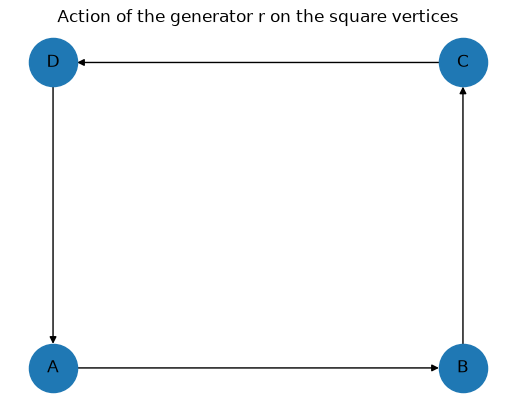

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Add the four vertices of the square.
G.add_nodes_from(vertices)

# Add the arrows describing the action of the 90-degree rotation.
for v in vertices:
    G.add_edge(v, rotation_action[v])

pos = {
    "A": (-1, -1),
    "B": (1, -1),
    "C": (1, 1),
    "D": (-1, 1),
}

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=1200,
    arrows=True,
)

plt.title("Action of the generator r on the square vertices")
plt.axis("off")
plt.show()


## 11. Orbits

Given an action of $G$ on $X$, the **orbit** of $x\in X$ is

$$
\operatorname{Orb}(x)
=
\{g\cdot x\mid g\in G\}.
$$

The orbit consists of everything that can be reached from $x$ by applying elements of the
group.

For the action of $C_4$ on the vertices of a square,

$$
\operatorname{Orb}(A)=\{A,B,C,D\}.
$$

More generally, orbits partition a $G$-space into subsets of points related by the symmetry
represented by the group.

In [10]:
def orbit(group_elements, action, x):
    # Apply every group element to x and collect the results.
    return {action(g, x) for g in group_elements}


def c4_vertex_action(g, v):
    # g is an integer modulo 4 representing a 90-degree rotation.
    return rotate_vertex(v, g)


C4_elements = {0, 1, 2, 3}

print("Orbit of A:", orbit(C4_elements, c4_vertex_action, "A"))


Orbit of A: {'A', 'B', 'C', 'D'}


## 12. Invariance and equivariance

Let $G$ act on sets $X$ and $Y$.

A function

$$
f:X\to Y
$$

is **$G$-invariant** if

$$
f(g\cdot x)=f(x)
$$

for every $g\in G$ and $x\in X$.

The output does not change under the transformation.

A function is **$G$-equivariant** if

$$
f(g\cdot x)=g\cdot f(x).
$$

The output transforms in a predictable way along with the input.

These two notions are fundamental to GDL. The article emphasizes the distinction: invariant functions collapse an entire orbit to a single value, whereas equivariant functions preserve the transformation structure.

### Intuition

$$
\boxed{
\text{invariant: transformation in}
\;\longrightarrow\;
\text{same output}
}
$$

whereas

$$
\boxed{
\text{equivariant: transformation in}
\;\longrightarrow\;
\text{corresponding transformation out}.
}
$$

In [11]:
# An invariant function: all vertices of the square receive the same label.
def invariant_function(v):
    # The output does not depend on the transformed position.
    return "square"

# An equivariant function: map each vertex to its opposite vertex.
opposite = {
    "A": "C",
    "B": "D",
    "C": "A",
    "D": "B",
}

def equivariant_example(v):
    # This transformation commutes with the C4 rotation action.
    return opposite[v]

print("Invariant outputs:", {invariant_function(v) for v in vertices})
print("Equivariant example:", {v: equivariant_example(v) for v in vertices})


Invariant outputs: {'square'}
Equivariant example: {'A': 'C', 'B': 'D', 'C': 'A', 'D': 'B'}


## 13. Connection with Deep Learning

Groups become especially important in Deep Learning when we want a network to respect a
known symmetry.

The orange-box discussions around the group section of the Borde–Bronstein notes emphasize
three related ideas:

1. **group theory describes transformations and symmetries;**
2. **group actions make those transformations act on data;**
3. **invariant and equivariant maps provide mathematical constraints on neural-network layers.**

The same perspective appears throughout Geometric Deep Learning: rather than asking a network
to learn a symmetry entirely from data, we can build the symmetry into the architecture as an
inductive bias. 

### 13.1 Group symmetries as inductive biases

Suppose a transformation group $G$ acts on an input space $X$.

If the prediction should not change under transformations in $G$, we want

$$
f(g\cdot x)=f(x).
$$

This is an invariant prediction.

For example, if a classifier recognizes an object regardless of its orientation, a rotation
of the input should ideally leave the class label unchanged.

If instead the output is itself geometric—for example, a vector field, orientation, or feature
map—we may want

$$
f(g\cdot x)=g\cdot f(x).
$$

This is equivariance.

A useful design principle is therefore:

$$
\text{symmetry of the data}
\quad\Longrightarrow\quad
\text{equivariance/invariance constraint on the network}.
$$

### 13.2 CNN filters and translation equivariance

Ordinary CNNs provide a particularly important example.

Let $T_a$ denote translation by $a$ and let $K$ be a convolution operator. Under the usual
conventions,

$$
K(T_a f)=T_a(Kf).
$$

This is **translation equivariance**.

The key mechanism is **weight sharing**: the same local filter is applied at every spatial
location. The network therefore does not need a different set of parameters for each possible
location.

It is useful to be precise about the terminology.

The filter itself is not usually described as an invariant object. Rather, the **convolution
operator built from the shared filter is translation-equivariant**.

In schematic form,

$$
\boxed{
\text{translate input}
\rightarrow
\text{convolve}
}
$$

gives the same result as

$$
\boxed{
\text{convolve}
\rightarrow
\text{translate feature map}.
}
$$

This is one of the fundamental geometric ideas behind convolutional architectures.

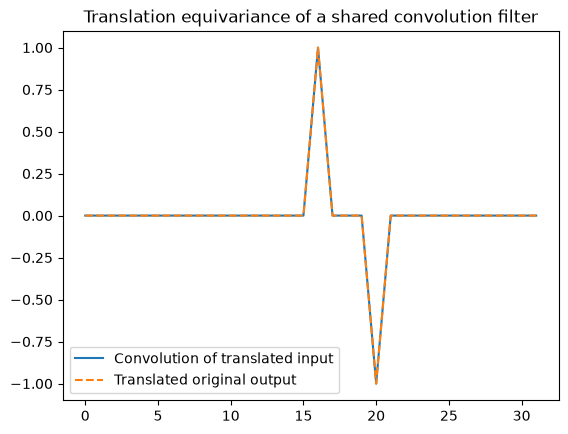

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Construct a simple one-dimensional signal with a localized feature.
x = np.zeros(32)
x[10:14] = 1.0

# A small filter detecting a rising/falling local pattern.
kernel = np.array([1.0, -1.0])

# Compute the convolution.
y = np.convolve(x, kernel, mode="same")

# Translate the input signal.
shift = 6
x_shifted = np.roll(x, shift)

# Apply the same shared filter after translation.
y_shifted = np.convolve(x_shifted, kernel, mode="same")

# Compare with translating the original feature map.
y_translated = np.roll(y, shift)

fig, ax = plt.subplots()

ax.plot(y_shifted, label="Convolution of translated input")
ax.plot(y_translated, "--", label="Translated original output")

ax.set_title("Translation equivariance of a shared convolution filter")
ax.legend()
plt.show()


### 13.3 Pooling: from equivariance toward invariance

Pooling requires a little more care.

A **local pooling layer** aggregates nearby values, for example with maximum or average
pooling. This can make a representation less sensitive to small spatial changes because
nearby activations are combined.

However, it is important not to overstate the mathematical property:

> ordinary strided pooling is not generally exactly invariant to arbitrary translations.

A shift of the input can change which values fall into each pooling window. In particular,
when the stride is larger than one, exact equivariance usually holds only for transformations
compatible with the pooling lattice, if at all.

Pooling is therefore better understood as a **coarsening operation that can introduce or
increase robustness/invariance to certain local transformations**, rather than as a universal
invariance mechanism.

There is a particularly clean case at the end of a network. If a feature map is globally
aggregated,

$$
y=\sum_{x\in X} f(x),
$$

then a permutation or translation of the spatial positions leaves $y$ unchanged, provided
the transformation simply permutes the positions and the aggregation is over all positions.

Thus global sum/mean/max pooling can produce an invariant representation.

In [13]:
# A simple illustration of global pooling.
feature_map = np.array([0.2, 1.5, 0.7, 2.0, 0.4])

# A translation/permutation of positions.
permuted = feature_map[[2, 4, 0, 3, 1]]

# Global pooling ignores the ordering of the entries.
sum_original = feature_map.sum()
sum_permuted = permuted.sum()

mean_original = feature_map.mean()
mean_permuted = permuted.mean()

max_original = feature_map.max()
max_permuted = permuted.max()

print("Original sum:", sum_original)
print("Permuted sum:", sum_permuted)

print("Original mean:", mean_original)
print("Permuted mean:", mean_permuted)

print("Original max:", max_original)
print("Permuted max:", max_permuted)


Original sum: 4.800000000000001
Permuted sum: 4.8
Original mean: 0.9600000000000002
Permuted mean: 0.96
Original max: 2.0
Permuted max: 2.0


### 13.4 Equivariant layers and invariant outputs

A useful architecture-level pattern is

$$
X
\xrightarrow{\text{equivariant}}
H_1
\xrightarrow{\text{equivariant}}
H_2
\xrightarrow{\cdots}
H_L
\xrightarrow{\text{invariant}}
Y.
$$

The intermediate representations transform in a controlled way under $G$, while the final
prediction is invariant.

This is especially useful for classification:

$$
x\mapsto g\cdot x
\quad\Longrightarrow\quad
f(x)=f(g\cdot x).
$$

Borde–Bronstein emphasize that stacking equivariant layers allows increasingly
complex features to be constructed while retaining the underlying symmetry, followed by a
final invariant operation when the task requires a symmetry-independent output.

An important conceptual point is that **equivariance is not merely a weaker form of
invariance**. They serve different roles:

- equivariance preserves information about how an object transforms;
- invariance deliberately removes dependence on the transformation.

A rought analogy is: "Equivariance to local, and Invariance to global." This will be made precise later when we discuss Lie Groups.

### 13.5 Group convolution

The group-theoretic version of convolution makes the connection even more explicit.

For a discrete group $G$, a schematic group convolution is

$$
(f\star\psi)(x)
=
\sum_{g\in G}
f(g\cdot x)\,\psi(g^{-1}).
$$

For a continuous group, the corresponding expression uses integration:

$$
(f\star\psi)(x)
=
\int_G
f(g\cdot x)\,\psi(g^{-1})\,dg.
$$

Borde–Bronstein explain that this operator is $G$-equivariant: transforming the
input before applying the convolution gives the same result as transforming the output after
the convolution.

The kernel $\psi$ assigns weights to contributions associated with group elements. This
generalizes the familiar idea of a convolution filter from translations to more general
symmetry groups.

In [14]:
# A finite toy group convolution over C4.
# Here f records four values on the four group elements.
f = np.array([1.0, 2.0, 0.5, -1.0])

# A simple kernel on C4.
psi = np.array([1.0, 0.5, -0.5, 0.25])

def cyclic_shift(signal, g):
    # Apply the cyclic action corresponding to g in C4.
    return np.roll(signal, -g)

def group_convolution(signal, kernel):
    # Sum contributions over the four group elements.
    result = 0.0

    for g in C4:
        # Evaluate the signal after the group transformation.
        transformed = cyclic_shift(signal, g)

        # In this toy scalar example, use the first component as a
        # simple stand-in for evaluation at a fixed point.
        result += transformed[0] * kernel[(-g) % 4]

    return result

print("Toy group convolution:", group_convolution(f, psi))


Toy group convolution: 0.75


### 13.6 The deeper GDL viewpoint

The important transition is from

$$
\text{ordinary function}
$$

to

$$
\text{function compatible with a group action}.
$$

In ordinary Deep Learning, we may simply learn

$$
f:X\to Y.
$$

In GDL, we often ask for the stronger structural condition

$$
f(g\cdot x)=g\cdot f(x)
$$

or

$$
f(g\cdot x)=f(x).
$$

This is where group theory stops being abstract algebra performed in isolation and becomes a
design language for neural networks.

Later, we will meet representations, vector spaces, convolutions, and eventually more general
geometric structures. The present notebook gives the algebraic vocabulary needed for those
developments.

## 14. Summary

The central ideas of this notebook are:

| Concept | Mathematical idea | GDL role |
|---|---|---|
| Group | $(G,\circ)$ satisfying group axioms | Symmetry transformations |
| Abelian group | $ab=ba$ | Commutative symmetries |
| Subgroup | $H\leq G$ | Smaller symmetry groups |
| Homomorphism | $\phi(ab)=\phi(a)\phi(b)$ | Structure-preserving maps |
| Isomorphism | Bijective homomorphism | Equivalent realizations of symmetry |
| Group action | $G\times X\to X$ | Transformations of data |
| Orbit | $G\cdot x$ | Set of symmetry-related inputs |
| Invariance | $f(gx)=f(x)$ | Transformation-independent output |
| Equivariance | $f(gx)=gf(x)$ | Predictable transformation of features |
| Group convolution | Weighted aggregation over $G$ | Equivariant neural operators |

A useful conceptual chain is

$$
\boxed{
\text{group}
\rightarrow
\text{group action}
\rightarrow
\text{orbit}
\rightarrow
\text{equivariance/invariance}
\rightarrow
\text{GDL architecture}.
}
$$

The key lesson is that **symmetry can be encoded as structure rather than learned only from
examples**. This is one of the central ideas that distinguishes Geometric Deep Learning from
a purely unconstrained approach to function approximation.

## Exercises

### Exercise 1 — Verify the group axioms

For $C_4$ under addition modulo $4$, verify computationally:

1. closure;
2. associativity;
3. existence of an identity;
4. existence of inverses.

### Exercise 2 — Find a non-abelian example

Use $S_3$ to find explicit permutations $p$ and $q$ such that

$$
p\circ q\neq q\circ p.
$$

### Exercise 3 — Subgroups

Find all subgroups of $C_4$ and verify them computationally.

### Exercise 4 — Homomorphism

Construct another homomorphism between two finite groups and verify

$$
\phi(ab)=\phi(a)\phi(b)
$$

for every pair of elements.

### Exercise 5 — Group action

Define the action of $C_4$ on the four vertices of a square and compute every orbit.

### Exercise 6 — Invariance versus equivariance

Construct:

1. an invariant function on the vertices of a square;
2. an equivariant function on the vertices of a square.

Verify the relevant identities computationally.

### Exercise 7 — CNN experiment

Construct a one-dimensional signal and a convolution kernel. Translate the signal and
experimentally test

$$
K(T_a f)=T_a(Kf).
$$

Then test a local pooling operation and investigate whether it is exactly invariant or merely
less sensitive to small translations.

### Exercise 8 — Your own examples and non-examples

Give one additional example and one non-example of each:

- a group;
- an abelian group;
- a subgroup;
- a homomorphism;
- an isomorphism;
- a group action;
- an invariant map;
- an equivariant map.

For at least one pair, explain carefully which group axiom or equivariance/invariance
condition fails in the non-example.

## References

1. **Haitz Sáez de Ocáriz Borde and Michael Bronstein**, *Mathematical Foundations of Geometric Deep Learning*, arXiv:2508.02723 (2025), especially §1.2, “Groups.”  
   https://arxiv.org/abs/2508.02723

2. **Michael M. Bronstein, Joan Bruna, Taco Cohen, and Petar Veličković**, *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*, arXiv:2104.13478 (2021).  
   https://arxiv.org/abs/2104.13478

3. **Michael Artin**, *Algebra*, Pearson / Prentice Hall. A standard graduate-level introduction to abstract algebra, including groups, group actions, homomorphisms, permutation groups, and related algebraic structures.

4. **J. B. Fraleigh**, *A First Course in Abstract Algebra*, Pearson. An accessible introduction to groups, subgroups, cyclic groups, permutations, homomorphisms, and isomorphisms.

### References for the GDL connection

The discussion of group actions, invariance, equivariance, and group convolution follows the mathematical connections made in §1.2 of Borde–Bronstein. Their notes explicitly connect group structure with symmetry and with the design of neural networks whose representations transform predictably under those symmetries.